# AR(2) Process Simulation and Prediction

$$y_t = 0.33y_{t-1}+0.50y_{t-2}$$

In [1]:
# 1000 Samples

from statsmodels.tsa.arima_process import ArmaProcess
import numpy as np

np.random.seed(42)

ma2 = np.array([1,0,0])
ar2 = np.array([1, -0.33, -0.50])

AR2_process = ArmaProcess(ar2, ma2).generate_sample(nsample=1000)

In [5]:
import matplotlib.font_manager as fm

for f in fm.fontManager.ttflist:
    if 'nanum' in f.name.lower():
        print(f.name, f.fname)

Nanum Gothic /System/Library/AssetsV2/com_apple_MobileAsset_Font7/bad9b4bf17cf1669dde54184ba4431c22dcad27b.asset/AssetData/NanumGothic.ttc


Matplotlib is building the font cache; this may take a moment.


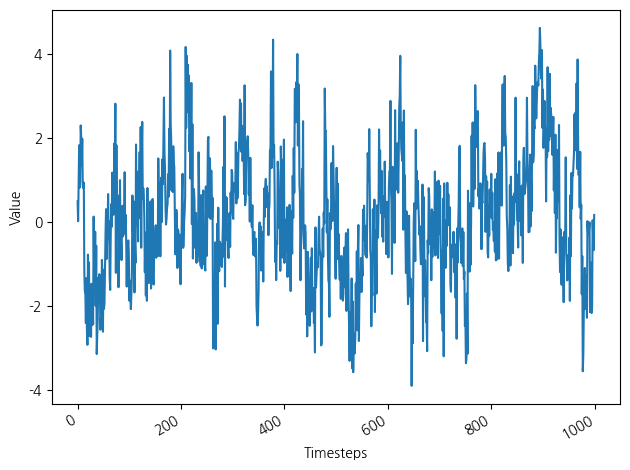

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Nanum Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


fig, ax = plt.subplots()

ax.plot(AR2_process)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

fig.autofmt_xdate()
plt.tight_layout()

## ADF Test

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(AR2_process)

print(f'ADF Stats: {ADF_result[0]}')
print(f'ADF P-val: {ADF_result[1]}')

ADF Stats: -7.566606021416879
ADF P-val: 2.914516129376722e-11


정상성 확인

## ACF 도식화

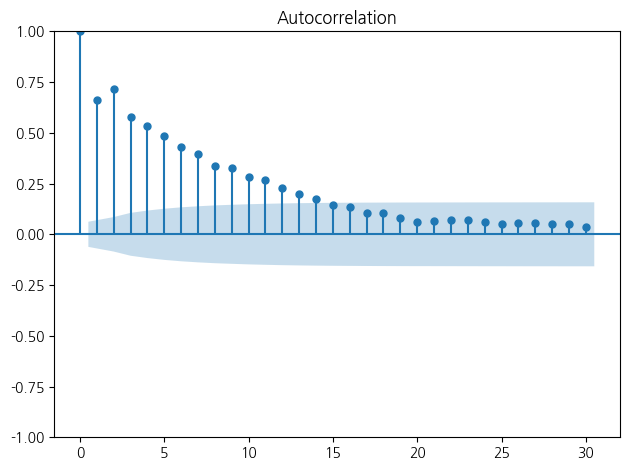

In [9]:
# 감쇄하고 있는가?

plot_acf(AR2_process, lags=30);

plt.tight_layout()

- lag 0 이후 유의한 coefficient 있으므로 random walk 아님
- 갑작스럽게 insignificant 영역으로 떨어지는 coefficient 없어서 moving average도 아님
- 자기회귀과정 내재되어 있을 가능성 있음

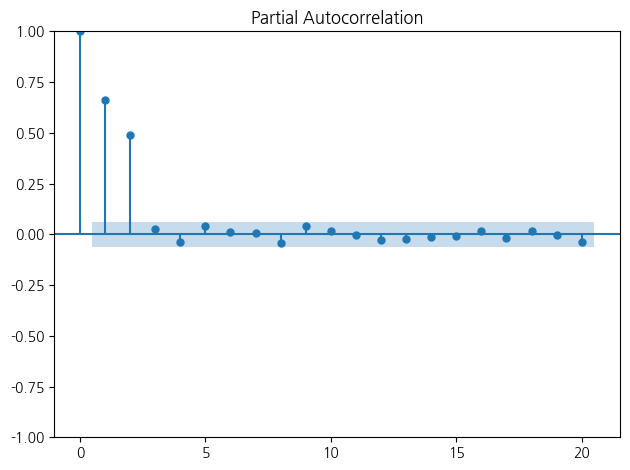

In [10]:
plot_pacf(AR2_process, lags=20)

plt.tight_layout()

지연 2까지 유의함 (p = 2)

## 훈련 집합 & 테스트 집합 분할

In [ ]:
import pandas as pd
df = pd.DataFrame({'value': AR2_process})
#여기서 있는 df의 value는 뭘 뜻하는거지?
# - 시뮬레이션된 시계열 값 1000개

train = df[:800]
test = df[800:]

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
def rolling_forecast(df: pd.DataFrame, train_len: int, 
                     horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'mean':
        pred_mean = []
        
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
            
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'AR':
        pred_AR = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(2,0,0))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)
            
        return pred_AR

pred_last = rolling 하면서 매 스텝마다 지금까지 알고 있는 데이터의 가장 마지막 관측값을 가져옴
 - 그 값을 그대로 다음 window 시점의 예측치로 복사해서 사용
 - 그 다음 i를 window 만큼 늘려 다시 그 시점까지의 마지막 값으로 다음 구간을 예측 (rolling forecast)

## 예측 수행

In [20]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

pred_mean = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_AR = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'AR')

test['pred_mean'] = pred_mean
test['pred_last_value'] = pred_last_value
test['pred_AR'] = pred_AR

test.head()

/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_28673/2796331969.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pred_mean'] = pred_mean
/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_28673/2796331969.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pred_last_value'] = pred_last_value
/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_28673/2796331969.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

,value,pred_mean,pred_last_value,pred_AR
800,1.153388,-0.049737,0.461912,0.208203
801,0.095529,-0.049737,0.461912,0.289199
802,0.704340,-0.048056,0.095529,0.586307
803,-0.182079,-0.048056,0.095529,0.233598
804,-0.142412,-0.047287,-0.182079,0.281393


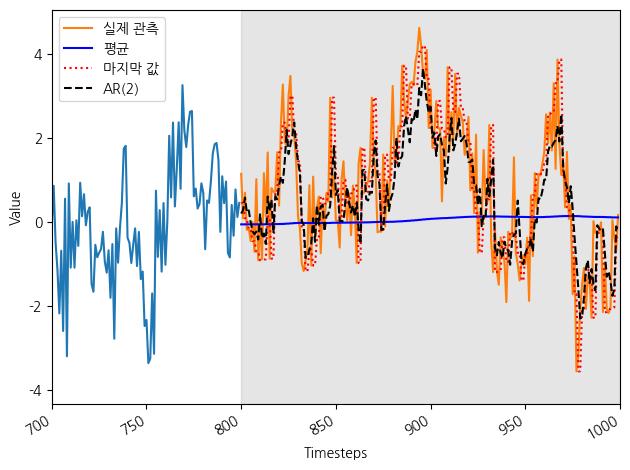

In [21]:
fig, ax = plt.subplots()

ax.plot(train)
ax.plot(test['value'], label = '실제 관측')
ax.plot(test['pred_mean'], 'b-', label = '평균')
ax.plot(test['pred_last_value'], 'r:', label = '마지막 값')
ax.plot(test['pred_AR'], 'k--', label = 'AR(2)')

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

ax.legend(loc = 'best')

ax.axvspan(800, 1000, color = '#808080', alpha = 0.2)
#testing area

plt.xlim(700, 1000)
fig.autofmt_xdate()
plt.tight_layout()

In [22]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['value'], test['pred_mean'])
mse_last = mean_squared_error(test['value'], test['pred_last_value'])
mse_AR = mean_squared_error(test['value'], test['pred_AR'])

print(mse_mean, mse_last, mse_AR)

3.088201680821444 1.2111519051869672 0.9692635186425079


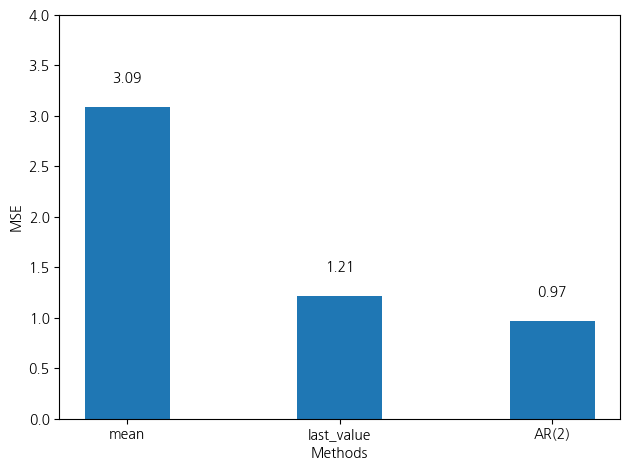

In [23]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'AR(2)']
y = [mse_mean, mse_last, mse_AR]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 4)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()

# AR(p) Process Simulation and Prediction

In [24]:
np.random.seed(42)

#now AR(3)
ma3 = np.array([1, 0, 0, 0])
ar3 = np.array([1, -0.33, -0.50, -0.07])

AR3_process = ArmaProcess(ar3, ma3).generate_sample(nsample=10000)